In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Cargar Datos

In [77]:
path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
ventas = pd.read_csv(path_ventas)
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_53639/3380775179.py:2: DtypeWarning: Columns (0: Cod Canal Comercial) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [78]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Kilos Nc', 'Monto Nc',
       'Factura Venta', 'Factura Kilos', 'Kilo Real', 'Monto Real', 'Precio',
       'Archivo', 'Hoja', 'Zona'],
      dtype='str')

In [79]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[
    (ventas["Nombre Consolidado"].isin(canales_relevantes)) &
    (ventas["Cod Canal Comercial"] == "CB")
    ]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 3090644


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [80]:
# Filtrar a solo segundo semestre de 2025
path_output = "caracteristicas_clientes_ult_6_meses.csv"
ventas = ventas[
    ((ventas["Año"] == 2025) & (ventas["Mes"] >= 10)) |
    (ventas["Año"] == 2026)
]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar fechas - Filas: 3090644


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [81]:
path_productos = "datos/Maestro Productos.xlsx"
productos = pd.read_excel(path_productos, header=2)
productos.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [82]:
productos.columns

Index(['Material', 'Texto breve de material', 'Material - COD SKU',
       'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
       'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

In [83]:
# Index(['Material', 'Texto breve de material', 'Material - COD SKU',
#        'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
#        'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

In [84]:
# Agregar a ventas información de producto según SKU
# Agregamos la denominación asociada a Gr. Empaq y la Denominación asociada a Gr. Carga
ventas = ventas.merge(
    productos[["Material", "Denom..2", "Denominación.2"]],
    left_on="Cod SKU",
    right_on="Material",
    how="left",
)
# Cambiar nombre de columnas para evitar confusión
ventas.rename(columns={"Denom..2": "Empaque", "Denominación.2": "Carga"}, inplace=True)
ventas.head()

,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona,Material,Empaque,Carga
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,6776,ENVASADO,ENVASES
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,399,GRANEL,PIEZAS PESO ESTÁNDAR
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,8777,ENVASADO,VIENESAS
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2,3149,ENVASADO,PATES
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO,8508,GRANEL,PIEZAS PESO ESTÁNDAR


# 1. Calcular variables por cliente

In [85]:
# Armar dataframe de clientes al que le iremos agregando columnas de las variables a usar para clusterizar/segmentar
segmentacion_clientes = ventas[["Cod Cliente"]].drop_duplicates().reset_index(drop=True)
print("Número de clientes únicos:", segmentacion_clientes.shape[0])
segmentacion_clientes.head()

Número de clientes únicos: 38306


,Cod Cliente
0,1199536
1,1178409
2,1096778
3,1151218
4,1000127


## 1.1 Tamaño de compra

In [86]:
# Agregamos venta neta total por cliente
venta_neta_cliente = ventas.groupby("Cod Cliente")["Monto Real"].sum().reset_index()
segmentacion_clientes = segmentacion_clientes.merge(venta_neta_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,Monto Real
0,1199536,585105
1,1178409,2097246
2,1096778,6157719
3,1151218,1750131
4,1000127,271058


In [87]:
# Agregamos número de facturas por cliente
num_facturas_cliente = ventas.groupby("Cod Cliente")["N° Factura"].nunique().reset_index().rename(columns={"Monto Real": "n_facturas"})
segmentacion_clientes = segmentacion_clientes.merge(num_facturas_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.rename(columns={"Monto Real": "venta_total_clp", "N° Factura": "n_facturas"}, inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas
0,1199536,585105,22
1,1178409,2097246,19
2,1096778,6157719,22
3,1151218,1750131,20
4,1000127,271058,9


In [88]:
# Agregamos ticket promedio por cliente
segmentacion_clientes["ticket_promedio"] = segmentacion_clientes["venta_total_clp"] / segmentacion_clientes["n_facturas"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio
0,1199536,585105,22,26595.681818
1,1178409,2097246,19,110381.368421
2,1096778,6157719,22,279896.318182
3,1151218,1750131,20,87506.550000
4,1000127,271058,9,30117.555556


In [89]:
# Agregamos desviación estandar del ticket por cliente
ticket_por_factura = (
    ventas.groupby(["Cod Cliente", "N° Factura"], as_index=False)
    .agg(ticket_factura=("Monto Real", "sum"))
)

ticket_desv_std_cliente = (
    ticket_por_factura.groupby("Cod Cliente")["ticket_factura"]
    .std()
    .reset_index(name="ticket_desv_std")
)

ticket_desv_std_cliente.rename(columns={"Monto Real": "ticket_desv_std"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(ticket_desv_std_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std
0,1199536,585105,22,26595.681818,11318.573805
1,1178409,2097246,19,110381.368421,53531.642320
2,1096778,6157719,22,279896.318182,89942.106524
3,1151218,1750131,20,87506.550000,55561.389468
4,1000127,271058,9,30117.555556,2845.885500


# 1.2 Frecuencia y recencia de compra

In [90]:
# Días promedio entre compras por cliente
# Fecha está en formato 20251002
ventas["Fecha Factura"] = pd.to_datetime(ventas["Fecha Factura"], format="%Y%m%d")

compras_por_dia = (
    ventas.groupby(["Cod Cliente", "Fecha Factura"], as_index=False)
    .size()
)

dias_entre_compras = (
    compras_por_dia
    .sort_values(["Cod Cliente", "Fecha Factura"])
    .groupby("Cod Cliente")["Fecha Factura"]
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index(name="dias_entre_compras")
)

segmentacion_clientes = segmentacion_clientes.merge(
    dias_entre_compras,
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras
0,1199536,585105,22,26595.681818,11318.573805,17.500000
1,1178409,2097246,19,110381.368421,53531.642320,10.937500
2,1096778,6157719,22,279896.318182,89942.106524,8.333333
3,1151218,1750131,20,87506.550000,55561.389468,10.937500
4,1000127,271058,9,30117.555556,2845.885500,21.875000


In [91]:
# Fecha de referencia para medir recencia
fecha_referencia = ventas["Fecha Factura"].max() + pd.Timedelta(days=1)

# Última compra por cliente
recencia_clientes = (
    ventas.groupby("Cod Cliente")["Fecha Factura"]
    .max()
    .reset_index(name="ultima_compra")
)

# Recencia en días
recencia_clientes["recencia"] = (
    fecha_referencia - recencia_clientes["ultima_compra"]
).dt.days

# Merge con tu tabla de segmentación
segmentacion_clientes = segmentacion_clientes.merge(
    recencia_clientes[["Cod Cliente", "recencia"]],
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7


# 1.3 Composición de compra

In [92]:
# Cantidad de SKUs distintos comprados por cliente
skus_distintos_cliente = ventas.groupby("Cod Cliente")["Cod SKU"].nunique().reset_index()
skus_distintos_cliente.rename(columns={"Cod SKU": "skus_distintos"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(skus_distintos_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5


In [93]:
# Share de cada marca por cliente en porcentaje del monto total comprado por el cliente
marcas = ["LA PREFERIDA", "SAN JORGE", "WINTER", "Los Nogales"]
for marca in marcas:
    share_marca_cliente = ventas[ventas["Nombre Marca"] == marca].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_marca_cliente.rename(columns={"Monto Real": f"share_marca_{marca}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_marca_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_marca_{marca}"] = segmentacion_clientes[f"share_marca_{marca}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_marca_WINTER,share_marca_Los Nogales
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,0.130448,0.183032
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,0.190610,0.085097
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,0.164667,0.020559
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,0.174280,0.399764
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,0.118757,0.809716


In [94]:
# Share de cada familia por cliente en porcentaje del monto total comprado por el cliente
familias = ventas["Nombre Familia"].unique()
for familia in familias:
    share_familia_cliente = ventas[ventas["Nombre Familia"] == familia].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_familia_cliente.rename(columns={"Monto Real": f"share_familia_{familia}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_familia_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_familia_{familia}"] = segmentacion_clientes[f"share_familia_{familia}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_ARROLLADOS,share_familia_HAMBURGUESAS,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,0.088687,NaN,0.194844,NaN,NaN,NaN,NaN,NaN,NaN
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,0.062594,NaN,NaN,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,0.066127,NaN,NaN,NaN,NaN,0.050510,NaN,NaN,NaN
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,0.046089,NaN,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,NaN,NaN,NaN,0.042917,NaN,NaN,NaN


In [95]:
# Share de cada empaque por cliente en porcentaje del monto total comprado por el cliente
empaques = ventas["Empaque"].unique()
for empaque in empaques:
    share_empaque_cliente = ventas[ventas["Empaque"] == empaque].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_empaque_cliente.rename(columns={"Monto Real": f"share_empaque_{empaque}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_empaque_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_empaque_{empaque}"] = segmentacion_clientes[f"share_empaque_{empaque}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,0.194844,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN


In [96]:
# # Share de cada carga por cliente en porcentaje del monto total comprado por el cliente
# cargas = ventas["Carga"].unique()
# for carga in cargas:
#     share_carga_cliente = ventas[ventas["Carga"] == carga].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
#     share_carga_cliente.rename(columns={"Monto Real": f"share__carga_{carga}"}, inplace=True)
#     segmentacion_clientes = segmentacion_clientes.merge(share_carga_cliente, on="Cod Cliente", how="left")
#     segmentacion_clientes[f"share__carga_{carga}"] = segmentacion_clientes[f"share__carga_{carga}"] / segmentacion_clientes["venta_total_clp"]
# segmentacion_clientes.head()

In [97]:
# HHI de marcas por cliente - medida de concentración de compra en una marca (entre más cerca a 1, más concentrado en una marca)
segmentacion_clientes["hhi_marcas"] = 0
for marca in marcas:
    segmentacion_clientes["hhi_marcas"] += (segmentacion_clientes[f"share_marca_{marca}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,0.194844,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072,0.400947
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237,0.320545
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566,0.526722
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395,0.284383
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN,0.673222


In [98]:
# HHI de familias por cliente - medida de concentración de compra en una familia (entre más cerca a 1, más concentrado en una familia)
segmentacion_clientes["hhi_familias"] = 0
for familia in familias:
    segmentacion_clientes["hhi_familias"] += (segmentacion_clientes[f"share_familia_{familia}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas,hhi_familias
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072,0.400947,NaN
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237,0.320545,NaN
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566,0.526722,NaN
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395,0.284383,NaN
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN,0.673222,NaN


In [99]:
share_cols = [
    c for c in segmentacion_clientes.columns
    if c.startswith("share_marca_") or c.startswith("share_familia_")
]

segmentacion_clientes[share_cols] = segmentacion_clientes[share_cols].fillna(0)

## 1.4 Categóricas del Cliente

In [100]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

,Zona,Distrito,CodJV,CodSup,CodVend,NombreVendedor,Canal,SubCanal,CodCliente Padre,Cliente Padre,...,MA,MI,JU,VI,SA,Frecuencia,Tratamiento,CodPago,DesPago,Estado
0,SANTIAGO,SANTIAGO CENTRO COSTA,854,854,1084869,ALEXIS PEREZ MUÑOZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,1.0,0,1.0,Cliente,C005,FIRMA 7 DIAS,1
1,SUR 1,RANCAGUA,481,481,482,JUAN FARIAS PEREZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,0.0,0,0.5,Cliente,C000,EFECTIVO - CHEQUE AL DIA,1
2,SUR 2,CONCEPCION SUR,1178566,1178566,1084857,ALEX RIOS CUEVAS,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.5,0.0,0,0.5,Cliente,C017,EFECTIVO,1
3,SUR 1,TALCA,581,581,1160963,RODRIGO AVENDAÑO HERNANDEZ,COBERTURA,COBERTURA,0,-,...,0.0,1.0,0.0,0.0,0,1.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1
4,NORTE 2,VIÑA COSTA,1216438,1216438,1206012,PAULO RUZ BILBAO,COBERTURA,COBERTURA,0,-,...,1.0,0.0,0.0,1.0,0,2.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1


In [101]:
clientes.columns

Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
       'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
       'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
       'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
       'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
       'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
       'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
      dtype='str')

In [102]:
# COLS: 
# Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
    # 'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
    # 'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
    # 'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
    # 'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
    # 'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
    # 'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
    # dtype='str')

In [103]:
# Agregar Zona, Distrito, Comuna, Canal, Subcanal, TipoNeg a segmentacion_clientes
segmentacion_clientes = segmentacion_clientes.merge(clientes[["CodCliente", "Zona", "Distrito", "Comuna", "Canal", "SubCanal", "TipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
segmentacion_clientes.drop(columns=["CodCliente"], inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas,hhi_familias,Zona,Distrito,Comuna,Canal,SubCanal,TipoNeg
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,0.819928,0.180072,0.400947,NaN,SUR 1,TALCA,LINARES,COBERTURA,COBERTURA,AL
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,0.246763,0.753237,0.320545,NaN,NORTE 2,VIÑA INTERIOR,QUILLOTA,COBERTURA,COBERTURA,AL
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,0.277434,0.722566,0.526722,NaN,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,VOLUMEN COBERTURA,AL
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,0.730605,0.269395,0.284383,NaN,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,COBERTURA,AL
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,1.000000,NaN,0.673222,NaN,NORTE 2,SAN FELIPE,LOS ANDES,COBERTURA,COBERTURA,AL


In [104]:
# Variables disponibles
vars_disponibles = segmentacion_clientes.columns.tolist()
print(f"Variables disponibles para segmentación: {len(vars_disponibles)}")
for var in vars_disponibles:
    print(var)

Variables disponibles para segmentación: 42
Cod Cliente
venta_total_clp
n_facturas
ticket_promedio
ticket_desv_std
dias_entre_compras
recencia
skus_distintos
share_marca_LA PREFERIDA
share_marca_SAN JORGE
share_marca_WINTER
share_marca_Los Nogales
share_familia_LACTEOS
share_familia_MORTADELAS
share_familia_VIENESAS
share_familia_PATE
share_familia_QUESOS
share_familia_HORTALIZAS
share_familia_JAMON G1
share_familia_SNACKS
share_familia_SALAMES
share_familia_JAMON G2
share_familia_ARROLLADOS
share_familia_HAMBURGUESAS
share_familia_OTROS COMERCIALIZADORA
share_familia_CARNES
share_familia_TIPICOS
share_familia_FIAMBRES
share_familia_PARRILLEROS
share_familia_TOCINOS
share_familia_EMPANIZADOS
share_familia_SECOS
share_empaque_ENVASADO
share_empaque_GRANEL
hhi_marcas
hhi_familias
Zona
Distrito
Comuna
Canal
SubCanal
TipoNeg


# 2. Funciones de iteracion


In [105]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PARAMETROS_KMEANS = {
    "random_state": 42,
    "n_init": 10,
}


def obtener_matriz_datos(df, columnas_variables, id_col="Cod Cliente"):
    """Selecciona la tabla cruda de clientes y variables que se usara para clusterizar."""
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df debe ser un DataFrame de pandas.")

    columnas_variables = list(columnas_variables)
    if not columnas_variables:
        raise ValueError("columnas_variables debe tener al menos una variable.")

    columnas_necesarias = [id_col] + columnas_variables
    columnas_faltantes = [col for col in columnas_necesarias if col not in df.columns]
    if columnas_faltantes:
        raise KeyError(f"Columnas faltantes en df: {columnas_faltantes}")

    matriz_datos = df[columnas_necesarias].copy()

    if matriz_datos[id_col].isna().any():
        raise ValueError(f"La columna {id_col} tiene valores nulos.")

    clientes_duplicados = matriz_datos[id_col].duplicated().sum()
    if clientes_duplicados > 0:
        raise ValueError(
            f"La matriz debe tener una fila por cliente. Hay {clientes_duplicados} filas duplicadas en {id_col}."
        )

    return matriz_datos.reset_index(drop=True)


def preprocesar_matriz(matriz_datos, id_col="Cod Cliente", scaler=None, pca_n_components=0.95):
    """Transforma la matriz cruda en variables escaladas y reducidas con PCA."""
    if not isinstance(matriz_datos, pd.DataFrame):
        raise TypeError("matriz_datos debe ser un DataFrame de pandas.")
    if id_col not in matriz_datos.columns:
        raise KeyError(f"No se encontro la columna identificadora: {id_col}")

    variables_crudas = matriz_datos.drop(columns=[id_col]).copy()
    if variables_crudas.empty:
        raise ValueError("matriz_datos no contiene variables para preprocesar.")

    columnas_categoricas = variables_crudas.select_dtypes(include=["object", "category", "string", "bool"]).columns
    features = pd.get_dummies(
        variables_crudas,
        columns=columnas_categoricas,
        dummy_na=False,
    )
    features = features.replace([np.inf, -np.inf], np.nan).fillna(0)

    if features.empty:
        raise ValueError("No quedaron columnas disponibles despues del preprocesamiento.")

    scaler = scaler if scaler is not None else RobustScaler()
    matriz_escalada = scaler.fit_transform(features)

    pca = None
    matriz_preprocesada = matriz_escalada
    if pca_n_components is not None:
        max_componentes = min(matriz_escalada.shape[0], matriz_escalada.shape[1])
        if max_componentes < 1:
            raise ValueError("No hay suficientes datos para aplicar PCA.")
        if isinstance(pca_n_components, int):
            pca_n_components = min(pca_n_components, max_componentes)

        pca = PCA(n_components=pca_n_components, svd_solver="full")
        matriz_preprocesada = pca.fit_transform(matriz_escalada)

    objetos_preprocesamiento = {
        "features": features,
        "columnas_features": features.columns.tolist(),
        "scaler": scaler,
        "pca": pca,
    }
    return matriz_preprocesada, objetos_preprocesamiento


def obtener_segmentacion_clientes(matriz_datos, matriz_preprocesada, k, id_col="Cod Cliente"):
    """Calcula clusters KMeans para un k dado y devuelve la segmentacion por cliente."""
    if id_col not in matriz_datos.columns:
        raise KeyError(f"No se encontro la columna identificadora: {id_col}")

    matriz_preprocesada = np.asarray(matriz_preprocesada)
    n_clientes = matriz_preprocesada.shape[0]
    if len(matriz_datos) != n_clientes:
        raise ValueError("matriz_datos y matriz_preprocesada deben tener la misma cantidad de filas.")
    if k < 2 or k > n_clientes:
        raise ValueError(f"k debe estar entre 2 y {n_clientes}.")

    modelo = KMeans(
        n_clusters=k,
        **PARAMETROS_KMEANS,
    )
    clusters = modelo.fit_predict(matriz_preprocesada) + 1

    return pd.DataFrame(
        {
            id_col: matriz_datos[id_col].to_numpy(),
            "cluster": clusters,
        }
    )


def buscar_mejor_k_por_silueta(matriz_preprocesada, ks, sample_size=15000, random_state=42):
    """Evalua una lista de k y marca el k con mayor silhouette score."""
    matriz_preprocesada = np.asarray(matriz_preprocesada)
    n_clientes = matriz_preprocesada.shape[0]
    ks_validos = [int(k) for k in ks if 2 <= int(k) <= n_clientes - 1]
    if not ks_validos:
        raise ValueError(f"No hay k validos. Usa valores entre 2 y {n_clientes - 1}.")

    tamano_muestra = min(int(sample_size), n_clientes)
    indices_totales = np.arange(n_clientes)
    rng = np.random.default_rng(random_state)
    resultados = []

    for k in ks_validos:
        modelo = KMeans(
            n_clusters=k,
            **PARAMETROS_KMEANS,
        )
        labels = modelo.fit_predict(matriz_preprocesada)
        labels_unicos = np.unique(labels)
        n_clusters_efectivos = len(labels_unicos)

        resultado = {
            "k": k,
            "silhouette_score": np.nan,
            "clusters_efectivos": n_clusters_efectivos,
        }

        if n_clusters_efectivos < 2:
            resultados.append(resultado)
            continue

        if tamano_muestra >= n_clientes:
            indices_eval = indices_totales
        else:
            indices_obligatorios = np.array(
                [
                    rng.choice(np.flatnonzero(labels == label))
                    for label in labels_unicos
                ],
                dtype=int,
            )
            restantes = max(tamano_muestra - len(indices_obligatorios), 0)
            universo = np.setdiff1d(indices_totales, indices_obligatorios, assume_unique=False)
            indices_extra = rng.choice(
                universo,
                size=min(restantes, len(universo)),
                replace=False,
            )
            indices_eval = np.concatenate([indices_obligatorios, indices_extra])
            rng.shuffle(indices_eval)

        labels_eval = labels[indices_eval]
        if np.unique(labels_eval).size >= 2:
            resultado["silhouette_score"] = silhouette_score(
                matriz_preprocesada[indices_eval],
                labels_eval,
            )

        resultados.append(resultado)

    resultados_silueta = pd.DataFrame(resultados)
    resultados_validos = resultados_silueta.dropna(subset=["silhouette_score"]).copy()
    if resultados_validos.empty:
        raise ValueError("No fue posible calcular silhouette para ningun k.")

    mejor_k = int(resultados_validos.loc[resultados_validos["silhouette_score"].idxmax(), "k"])
    resultados_silueta["mejor_k"] = resultados_silueta["k"].eq(mejor_k)
    return resultados_silueta


def observar_correlaciones(df, columnas_variables, metodo="pearson"):
    """Muestra y devuelve la matriz de correlacion para las variables indicadas."""
    columnas_variables = list(columnas_variables)
    columnas_faltantes = [col for col in columnas_variables if col not in df.columns]
    if columnas_faltantes:
        raise KeyError(f"Columnas faltantes en df: {columnas_faltantes}")

    datos = df[columnas_variables].copy()
    columnas_no_numericas = datos.select_dtypes(exclude=np.number).columns.tolist()
    if columnas_no_numericas:
        raise TypeError(f"La correlacion requiere variables numericas. Revisa: {columnas_no_numericas}")

    correlaciones = datos.replace([np.inf, -np.inf], np.nan).corr(method=metodo)

    plt.figure(figsize=(max(6, len(columnas_variables) * 0.8), max(5, len(columnas_variables) * 0.6)))
    sns.heatmap(
        correlaciones,
        cmap="coolwarm",
        center=0,
        annot=len(columnas_variables) <= 12,
        fmt=".2f",
        square=True,
        linewidths=0.5,
    )
    plt.title("Correlacion entre variables seleccionadas")
    plt.tight_layout()
    plt.show()

    return correlaciones


def resumir_variables_por_cluster(matriz_datos, segmentacion, columnas_variables=None, id_col="Cod Cliente"):
    """Entrega promedio y desviacion estandar de cada variable original por cluster."""
    if id_col not in matriz_datos.columns:
        raise KeyError(f"No se encontro {id_col} en matriz_datos.")
    if id_col not in segmentacion.columns or "cluster" not in segmentacion.columns:
        raise KeyError(f"segmentacion debe contener {id_col} y cluster.")

    if columnas_variables is None:
        columnas_variables = [col for col in matriz_datos.columns if col != id_col]
    else:
        columnas_variables = list(columnas_variables)

    columnas_faltantes = [col for col in columnas_variables if col not in matriz_datos.columns]
    if columnas_faltantes:
        raise KeyError(f"Columnas faltantes en matriz_datos: {columnas_faltantes}")

    columnas_no_numericas = matriz_datos[columnas_variables].select_dtypes(exclude=np.number).columns.tolist()
    if columnas_no_numericas:
        raise TypeError(f"El resumen requiere variables numericas. Revisa: {columnas_no_numericas}")

    datos_cluster = matriz_datos.merge(segmentacion[[id_col, "cluster"]], on=id_col, how="left")
    if datos_cluster["cluster"].isna().any():
        raise ValueError("Hay clientes sin cluster asignado.")

    promedios = (
        datos_cluster.groupby("cluster")[columnas_variables]
        .mean()
        .reset_index()
        .melt(id_vars="cluster", var_name="variable", value_name="promedio")
    )
    desviaciones = (
        datos_cluster.groupby("cluster")[columnas_variables]
        .std()
        .reset_index()
        .melt(id_vars="cluster", var_name="variable", value_name="desviacion_estandar")
    )
    n_clientes = (
        datos_cluster.groupby("cluster")[id_col]
        .nunique()
        .rename("n_clientes")
        .reset_index()
    )

    resumen = (
        promedios
        .merge(desviaciones, on=["cluster", "variable"], how="left")
        .merge(n_clientes, on="cluster", how="left")
        .sort_values(["cluster", "variable"])
        .reset_index(drop=True)
    )
    return resumen


# 3. Iteracion de clusterizacion


In [106]:
segmentacion_clientes["cv_ticket"] = segmentacion_clientes["ticket_desv_std"] / segmentacion_clientes["ticket_promedio"]

In [107]:
familias_principales = [
    "VIENESAS",
    "MORTADELAS",
    "JAMON G1",
    "JAMON G2",
    "QUESOS",
    "PARRILLEROS",
    "HAMBURGUESAS",
]

cols_familias_principales = [
    f"share_familia_{f}" for f in familias_principales
]

segmentacion_clientes["share_familia_OTRAS"] = (
    1 - segmentacion_clientes[cols_familias_principales].sum(axis=1)
).clip(lower=0)

In [ ]:
columnas_actuales = [
    "Cod Cliente",
    # "venta_total_clp",
    "n_facturas",
    "ticket_promedio",
    # "ticket_desv_std",
    "cv_ticket",
    # "dias_entre_compras",
    "recencia",
    "skus_distintos",
    "share_marca_LA PREFERIDA",
    "share_marca_SAN JORGE",
    "share_marca_WINTER",
    # "share_marca_Los Nogales",
    "hhi_marcas",
    # "share_familia_LACTEOS",
    "share_familia_MORTADELAS",
    "share_familia_VIENESAS",
    # "share_familia_PATE",
    "share_familia_QUESOS",
    # "share_familia_HORTALIZAS",
    "share_familia_JAMON G1",
    # "share_familia_SNACKS",
    # "share_familia_SALAMES",
    "share_familia_JAMON G2",
    # "share_familia_ARROLLADOS",
    "share_familia_HAMBURGUESAS",
    # "share_familia_OTROS COMERCIALIZADORA",
    # "share_familia_CARNES",
    # "share_familia_TIPICOS",
    # "share_familia_FIAMBRES",
    "share_familia_PARRILLEROS",
    # "share_familia_TOCINOS",
    # "share_familia_EMPANIZADOS",
    # "share_familia_SECOS",
    "share_familia_OTRAS",
    "hhi_familias",
    # "share_empaque_ENVASADO",
    "share_empaque_GRANEL",
    # "share__carga_ENVASES",
    # "share__carga_PIEZAS PESO ESTÁNDAR",
    # "share__carga_VIENESAS",
    # "share__carga_PATES",
    # "share__carga_LAMINADOS",
    # "share__carga_PESO VARIABLE",
    # "share__carga_CONGELADOS",
    # "share__carga_FRESH PACK",
    # "share__carga_PARRILLEROS",
    # "share__carga_POUCH",
    # "share__carga_OTROS",
    #"Zona",
    #"Distrito",
    #"Comuna",
    #"Canal",
    #"SubCanal",
    #"TipoNeg",
]

In [158]:
columnas_v2  = [
    "Cod Cliente",
    # "venta_total_clp",
    "n_facturas",
    "ticket_promedio",
    # "ticket_desv_std",
    "cv_ticket",
    # "dias_entre_compras",
    "recencia",
    "skus_distintos",
    "share_marca_LA PREFERIDA",
    "share_marca_SAN JORGE",
    # "share_marca_WINTER",
    # "share_marca_Los Nogales",
    # "hhi_marcas",
    # "share_familia_LACTEOS",
    "share_familia_MORTADELAS",
    "share_familia_VIENESAS",
    # "share_familia_PATE",
    "share_familia_QUESOS",
    # "share_familia_HORTALIZAS",
    "share_familia_JAMON G1",
    # "share_familia_SNACKS",
    # "share_familia_SALAMES",
    "share_familia_JAMON G2",
    # "share_familia_ARROLLADOS",
    # "share_familia_HAMBURGUESAS",
    # "share_familia_OTROS COMERCIALIZADORA",
    # "share_familia_CARNES",
    # "share_familia_TIPICOS",
    # "share_familia_FIAMBRES",
    "share_familia_PARRILLEROS",
    # "share_familia_TOCINOS",
    # "share_familia_EMPANIZADOS",
    # "share_familia_SECOS",
    # "share_familia_OTRAS",
    "hhi_familias",
    # "share_empaque_ENVASADO",
    "share_empaque_GRANEL",
    # "share__carga_ENVASES",
    # "share__carga_PIEZAS PESO ESTÁNDAR",
    # "share__carga_VIENESAS",
    # "share__carga_PATES",
    # "share__carga_LAMINADOS",
    # "share__carga_PESO VARIABLE",
    # "share__carga_CONGELADOS",
    # "share__carga_FRESH PACK",
    # "share__carga_PARRILLEROS",
    # "share__carga_POUCH",
    # "share__carga_OTROS",
    #"Zona",
    #"Distrito",
    #"Comuna",
    #"Canal",
    #"SubCanal",
    #"TipoNeg",
]

In [159]:
share_cols = [
    c for c in segmentacion_clientes.columns
    if c.startswith("share_marca_")
    or c.startswith("share_familia_")
    or c.startswith("share_empaque_")
]

segmentacion_clientes[share_cols] = segmentacion_clientes[share_cols].fillna(0)

segmentacion_clientes["hhi_marcas"] = sum(
    segmentacion_clientes[f"share_marca_{m}"] ** 2
    for m in marcas
)

segmentacion_clientes["hhi_familias"] = sum(
    segmentacion_clientes[f"share_familia_{f}"] ** 2
    for f in familias
)

In [167]:
id_col = "Cod Cliente"
columnas_variables_rfm = ["ticket_promedio", "dias_entre_compras", "recencia"]
# columnas_variables_comportamiento = [c for c in columnas_actuales if c != id_col]
columnas_variables_comportamiento = [c for c in columnas_v2 if c != id_col]

# Cambia esta lista para probar otra combinacion de variables.
columnas_variables = columnas_variables_comportamiento
ks = range(8, 30)

print("Variables seleccionadas:")
for col in columnas_variables:
    print(f"- {col}")

columnas_matriz = [id_col] + columnas_variables
columnas_faltantes = [col for col in columnas_matriz if col not in segmentacion_clientes.columns]
if columnas_faltantes:
    raise KeyError(f"Columnas faltantes en segmentacion_clientes: {columnas_faltantes}")

data_clientes = segmentacion_clientes[columnas_matriz].copy()


Variables seleccionadas:
- n_facturas
- ticket_promedio
- cv_ticket
- recencia
- skus_distintos
- share_marca_LA PREFERIDA
- share_marca_SAN JORGE
- share_familia_MORTADELAS
- share_familia_VIENESAS
- share_familia_QUESOS
- share_familia_JAMON G1
- share_familia_JAMON G2
- share_familia_PARRILLEROS
- hhi_familias
- share_empaque_GRANEL


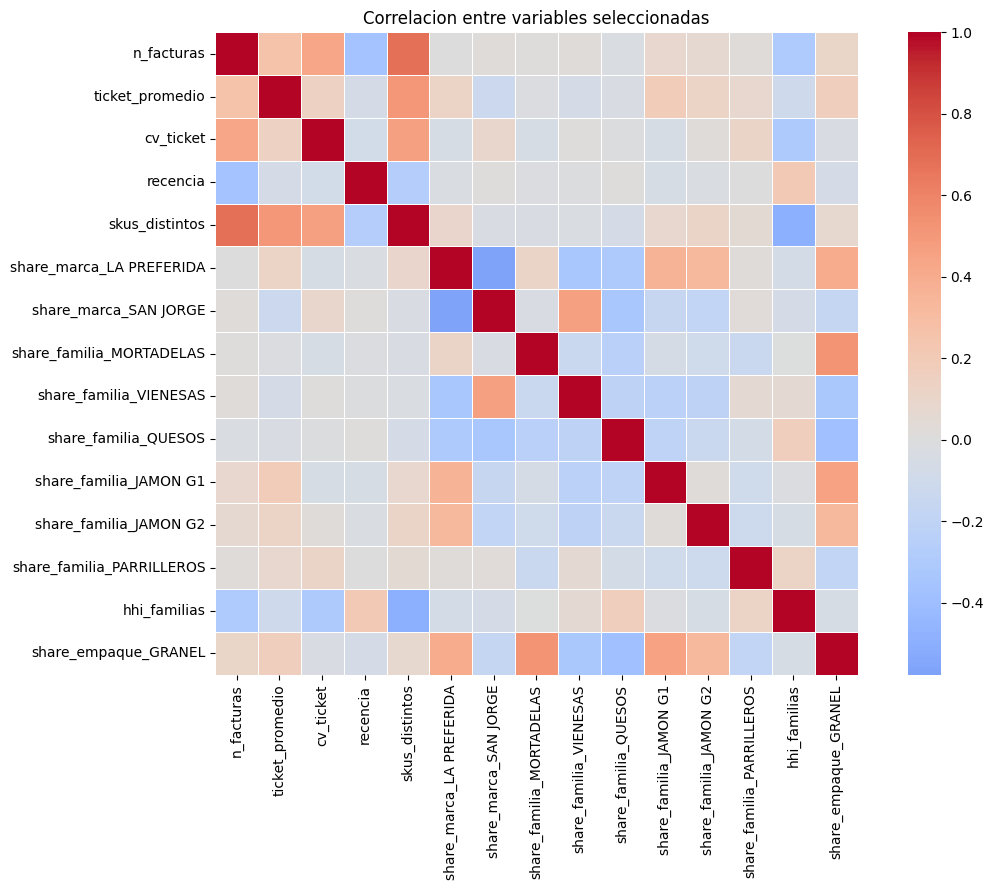

,n_facturas,ticket_promedio,cv_ticket,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_familia_MORTADELAS,share_familia_VIENESAS,share_familia_QUESOS,share_familia_JAMON G1,share_familia_JAMON G2,share_familia_PARRILLEROS,hhi_familias,share_empaque_GRANEL
n_facturas,1.000000,0.257614,0.438371,-0.365840,0.685783,0.006410,0.023866,0.011029,0.018908,-0.025188,0.078775,0.069152,0.024761,-0.297741,0.102712
ticket_promedio,0.257614,1.000000,0.136849,-0.070871,0.510781,0.124930,-0.122900,-0.021141,-0.064697,-0.034075,0.188321,0.124899,0.085222,-0.104323,0.162539
cv_ticket,0.438371,0.136849,1.000000,-0.082382,0.466674,-0.050288,0.093269,-0.052101,0.011993,-0.012578,-0.050093,0.024235,0.107730,-0.301125,-0.029892
recencia,-0.365840,-0.070871,-0.082382,1.000000,-0.266017,-0.024357,0.013009,-0.018440,-0.010493,0.014225,-0.052889,-0.028436,0.005819,0.214833,-0.065420
skus_distintos,0.685783,0.510781,0.466674,-0.266017,1.000000,0.098365,-0.035992,-0.034000,-0.027504,-0.061380,0.087958,0.117164,0.056933,-0.494628,0.073320
share_marca_LA PREFERIDA,0.006410,0.124930,-0.050288,-0.024357,0.098365,1.000000,-0.576978,0.115696,-0.338883,-0.306124,0.362766,0.326455,0.015479,-0.072023,0.399294
share_marca_SAN JORGE,0.023866,-0.122900,0.093269,0.013009,-0.035992,-0.576978,1.000000,-0.028906,0.458893,-0.339877,-0.161107,-0.176693,0.031386,-0.066524,-0.169476
share_familia_MORTADELAS,0.011029,-0.021141,-0.052101,-0.018440,-0.034000,0.115696,-0.028906,1.000000,-0.137604,-0.234345,-0.056528,-0.092166,-0.137291,-0.001058,0.529273
share_familia_VIENESAS,0.018908,-0.064697,0.011993,-0.010493,-0.027504,-0.338883,0.458893,-0.137604,1.000000,-0.211175,-0.228928,-0.207800,0.059215,0.062038,-0.322622
share_familia_QUESOS,-0.025188,-0.034075,-0.012578,0.014225,-0.061380,-0.306124,-0.339877,-0.234345,-0.211175,1.000000,-0.206004,-0.138248,-0.076569,0.172778,-0.379859


In [168]:
correlaciones_variables = observar_correlaciones(
    data_clientes,
    columnas_variables,
)
correlaciones_variables


In [169]:
matriz_datos = obtener_matriz_datos(
    data_clientes,
    columnas_variables,
)

matriz_preprocesada, objetos_preprocesamiento = preprocesar_matriz(
    matriz_datos,
    pca_n_components=0.99,
)

assert matriz_datos["Cod Cliente"].nunique() == matriz_datos.shape[0]
assert matriz_preprocesada.shape[0] == matriz_datos.shape[0]

print(f"Matriz cruda: {matriz_datos.shape}")
print(f"Matriz preprocesada: {matriz_preprocesada.shape}")
if objetos_preprocesamiento["pca"] is not None:
    varianza_explicada = objetos_preprocesamiento["pca"].explained_variance_ratio_.sum()
    print(f"Varianza explicada PCA: {varianza_explicada:.2%}")


Matriz cruda: (38306, 16)
Matriz preprocesada: (38306, 12)
Varianza explicada PCA: 99.15%


Mejor k segun silhouette: 16


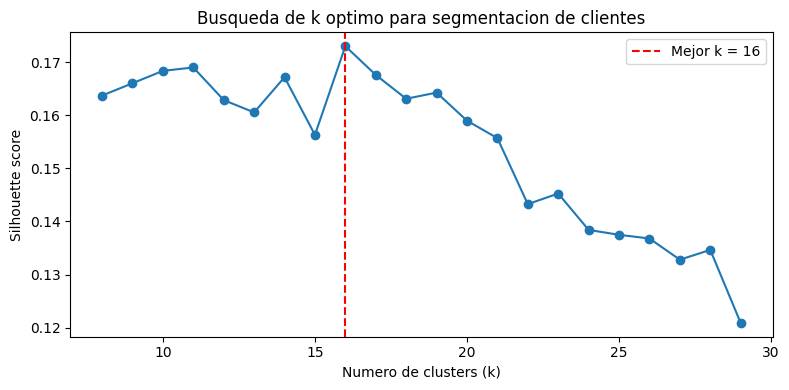

,k,silhouette_score,clusters_efectivos,mejor_k
0,8,0.163755,8,False
1,9,0.166077,9,False
2,10,0.168413,10,False
3,11,0.169054,11,False
4,12,0.162904,12,False
5,13,0.160576,13,False
6,14,0.167212,14,False
7,15,0.156336,15,False
8,16,0.173071,16,True
9,17,0.167649,17,False


In [170]:
resultados_silueta = buscar_mejor_k_por_silueta(
    matriz_preprocesada,
    ks,
    sample_size=15000,
    random_state=42,
)

mejor_k = int(resultados_silueta.loc[resultados_silueta["mejor_k"], "k"].iloc[0])
print(f"Mejor k segun silhouette: {mejor_k}")

plt.figure(figsize=(8, 4))
plt.plot(
    resultados_silueta["k"],
    resultados_silueta["silhouette_score"],
    marker="o",
)
plt.axvline(mejor_k, color="red", linestyle="--", label=f"Mejor k = {mejor_k}")
plt.xlabel("Numero de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Busqueda de k optimo para segmentacion de clientes")
plt.legend()
plt.tight_layout()
plt.show()

resultados_silueta


In [171]:
segmentacion_clusters = obtener_segmentacion_clientes(
    matriz_datos,
    matriz_preprocesada,
    mejor_k,
)

assert segmentacion_clusters.shape[0] == matriz_datos.shape[0]
assert segmentacion_clusters["cluster"].notna().all()

# Evita columnas duplicadas si esta celda se reejecuta.
data_clientes = (
    data_clientes
    .drop(columns=["cluster"], errors="ignore")
    .merge(segmentacion_clusters, on="Cod Cliente", how="left")
)

assert data_clientes["cluster"].notna().all()

segmentacion_clusters["cluster"].value_counts().sort_index()


cluster
1     3779
2      217
3     1905
4     4766
5     1198
6     1615
7      562
8     2845
9     5424
10     406
11    6899
12     127
13    1755
14    3286
15    3410
16     112
Name: count, dtype: int64

In [172]:
resumen_clusters = resumir_variables_por_cluster(
    matriz_datos,
    segmentacion_clusters,
    columnas_variables=columnas_variables,
)

assert set(resumen_clusters["variable"].unique()) == set(columnas_variables)
resumen_clusters


,cluster,variable,promedio,desviacion_estandar,n_clientes
0,1,cv_ticket,0.423154,0.173180,3779
1,1,hhi_familias,0.316740,0.147207,3779
2,1,n_facturas,15.307753,8.418561,3779
3,1,recencia,9.583752,7.863517,3779
4,1,share_empaque_GRANEL,0.177597,0.161715,3779
...,...,...,...,...,...
235,16,share_familia_VIENESAS,0.130553,0.116496,112
236,16,share_marca_LA PREFERIDA,0.397602,0.205843,112
237,16,share_marca_SAN JORGE,0.334757,0.159935,112
238,16,skus_distintos,51.973214,29.651264,112


In [173]:
resumen_clusters.to_csv("resumen_clusters.csv")

In [175]:
id_col = globals().get("id_col", "Cod Cliente")
columnas_variables_tabla = [col for col in columnas_variables if col not in [id_col, "cluster"]]

columnas_matriz_clientes = [id_col] + columnas_variables_tabla
columnas_faltantes_matriz = [col for col in columnas_matriz_clientes if col not in matriz_datos.columns]
if columnas_faltantes_matriz:
    raise KeyError(f"Columnas faltantes en matriz_datos: {columnas_faltantes_matriz}")

columnas_faltantes_segmentacion = [col for col in [id_col, "cluster"] if col not in segmentacion_clusters.columns]
if columnas_faltantes_segmentacion:
    raise KeyError(f"Columnas faltantes en segmentacion_clusters: {columnas_faltantes_segmentacion}")

tabla_clientes_clusters = (
    matriz_datos[columnas_matriz_clientes]
    .merge(segmentacion_clusters[[id_col, "cluster"]], on=id_col, how="left")
    .sort_values(["cluster", id_col])
    .reset_index(drop=True)
)

assert tabla_clientes_clusters.shape[0] == matriz_datos.shape[0]
assert tabla_clientes_clusters["cluster"].notna().all()
assert set(columnas_variables_tabla).issubset(tabla_clientes_clusters.columns)

tabla_clientes_clusters


,Cod Cliente,n_facturas,ticket_promedio,cv_ticket,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_familia_MORTADELAS,share_familia_VIENESAS,share_familia_QUESOS,share_familia_JAMON G1,share_familia_JAMON G2,share_familia_PARRILLEROS,hhi_familias,share_empaque_GRANEL,cluster
0,2260,21,53014.571429,0.286548,7,15,0.166209,0.268435,0.023952,0.121506,0.452151,0.000000,0.000000,0.000000,0.249814,0.000000,1
1,2682,13,62677.230769,0.282221,13,12,0.157934,0.032841,0.178949,0.042362,0.475527,0.000000,0.000000,0.000000,0.292150,0.178949,1
2,3775,20,128193.150000,0.378928,6,15,0.195173,0.108668,0.000000,0.000000,0.515284,0.081909,0.108668,0.000000,0.321471,0.190577,1
3,3889,10,32076.900000,0.098943,5,11,0.152340,0.212209,0.232304,0.163208,0.495282,0.000000,0.000000,0.000000,0.329000,0.232304,1
4,3972,5,37060.600000,0.601968,8,7,0.329746,0.017787,0.049816,0.000000,0.424737,0.000000,0.000000,0.000000,0.302581,0.049816,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38301,1238273,11,496994.909091,0.577054,4,10,0.061597,0.175594,0.411475,0.091183,0.000000,0.000000,0.425908,0.000000,0.361635,0.878550,16
38302,1240435,7,555743.857143,0.651328,7,32,0.637372,0.267336,0.056310,0.002871,0.053626,0.492028,0.210625,0.000000,0.313852,0.880681,16
38303,1240470,3,454221.333333,0.760649,29,37,0.545078,0.294895,0.013046,0.000000,0.102723,0.168119,0.263751,0.082829,0.141636,0.037160,16
38304,1241636,1,543000.000000,NaN,19,1,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,16


In [176]:
nombres_clusters = {
    1: "Queseros ticket medio-bajo",
    2: "Parrilleros con Vienesas",
    3: "Dormidos baja frecuencia",
    4: "Mortadelas granel",
    5: "Mixtos San Jorge",
    6: "Alto valor granel-jamones",
    7: "Grandes multiproducto frecuentes",
    8: "Jamón G2 granel",
    9: "Vienesas San Jorge bajo ticket",
    10: "Parrilleros mixtos",
    11: "Multiproducto frecuentes balanceados",
    12: "Parrilleros puros",
    13: "Rezagados canasta mixta",
    14: "Jamón G1 granel",
    15: "Multiproducto San Jorge",
    16: "Mega clientes multiproducto"
}

tabla_clientes_clusters["nombre_cluster"] = tabla_clientes_clusters["cluster"].map(nombres_clusters)

In [177]:
tabla_clientes_clusters.to_csv("segmentacion_clientes_comp_compra.csv")